In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv, LinAlgError, pinv

In [ ]:
data = pd.read_csv('csv_result-column_2C_weka.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        310 non-null    int64  
 1   pelvic_incidence          310 non-null    float64
 2   pelvic_tilt               310 non-null    float64
 3   lumbar_lordosis_angle     310 non-null    float64
 4   sacral_slope              310 non-null    float64
 5   pelvic_radius             310 non-null    float64
 6   degree_spondylolisthesis  310 non-null    float64
 7   class                     310 non-null    object 
dtypes: float64(6), int64(1), object(1)
memory usage: 19.5+ KB


In [ ]:
data.head()

,id,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,1,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,2,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,3,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,4,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,5,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [ ]:
data.describe()

,id,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,155.500000,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,89.633513,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,1.000000,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,78.250000,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,155.500000,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,232.750000,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,310.000000,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


# Scatterplots of the independent variables in the dataset


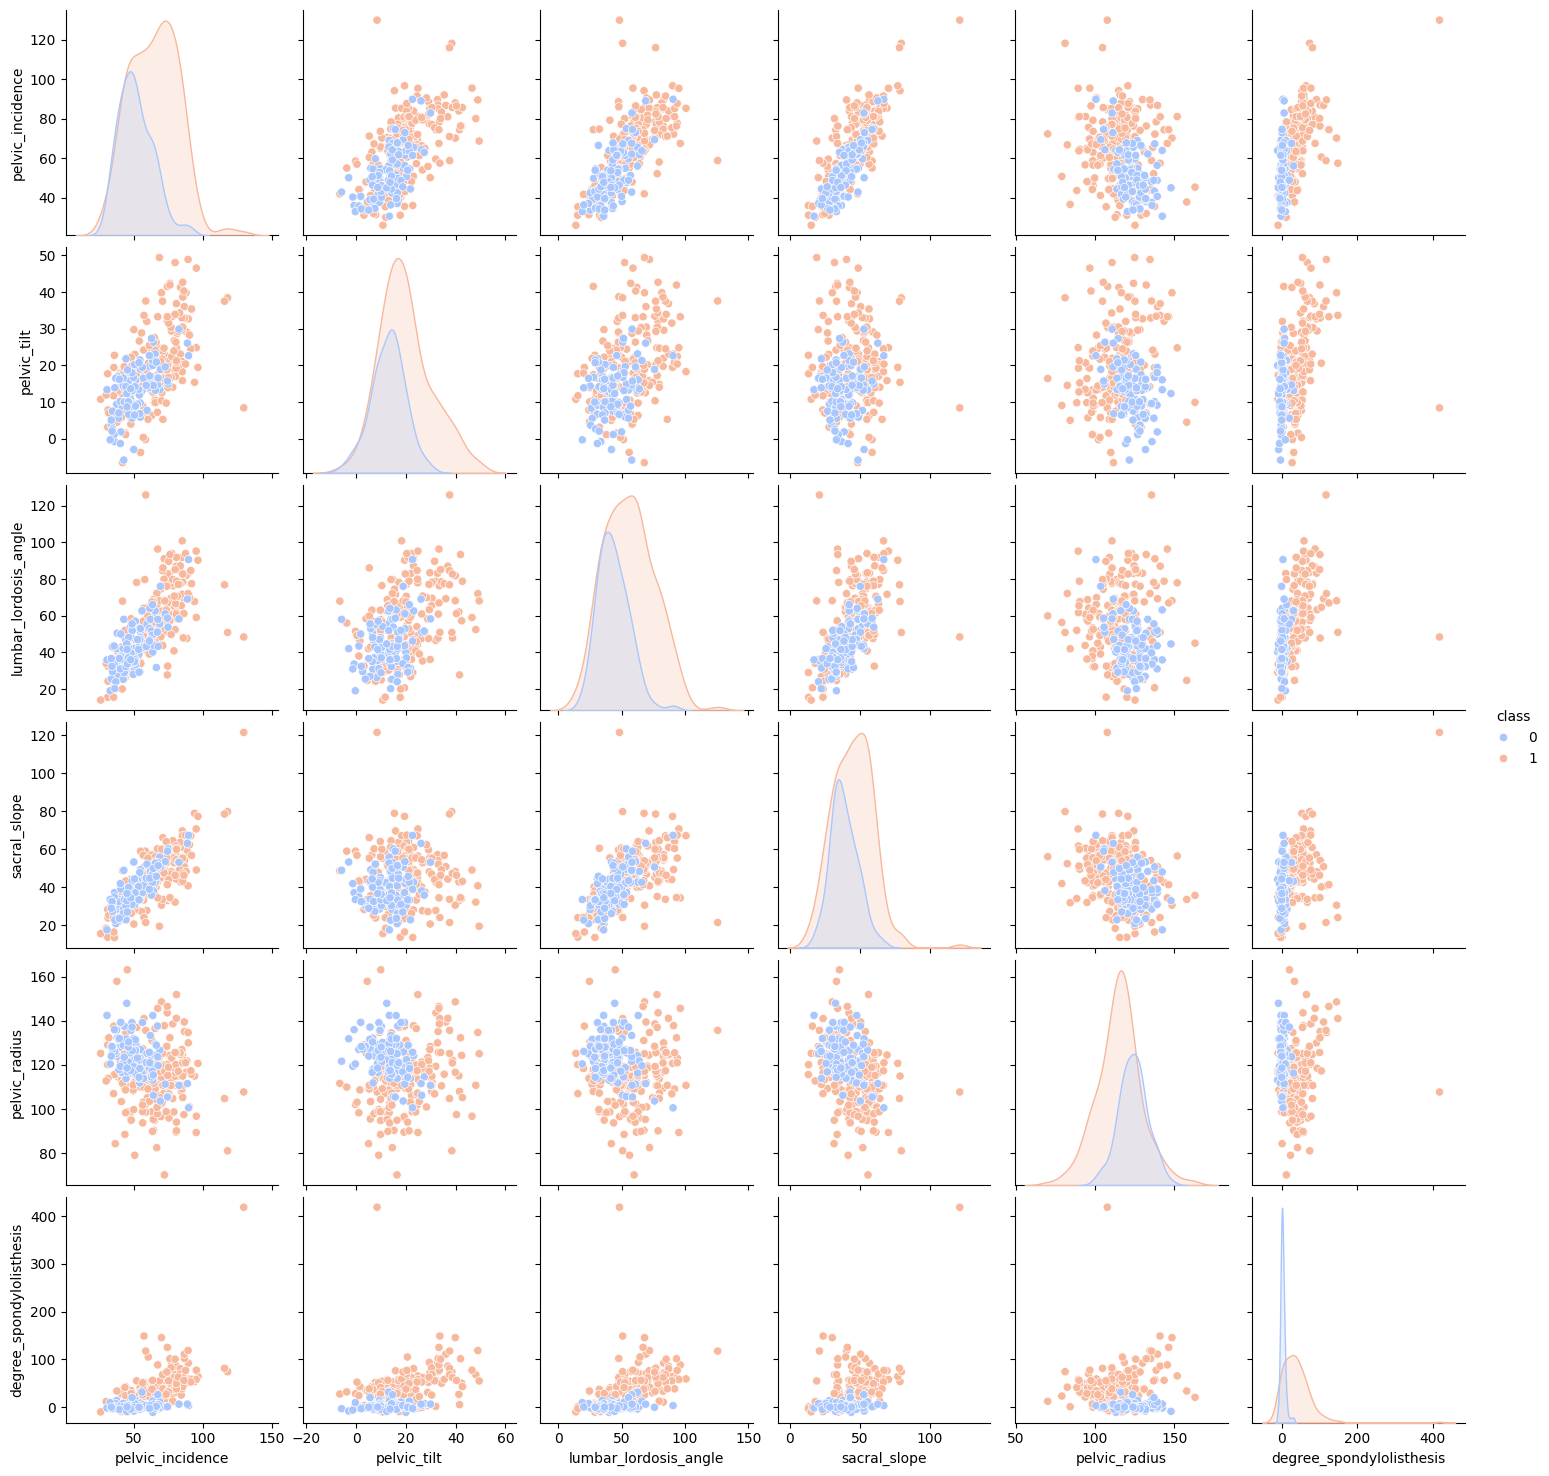

In [ ]:
data['class'] = data['class'].map({'Normal': 0, 'Abnormal': 1})

# Drop the ID column if it exists
data.drop(columns=['id'], inplace=True, errors='ignore')

# Create scatterplot matrix
sns.pairplot(data, hue="class", palette="coolwarm", diag_kind="kde")
plt.show()

#Boxplots for each of the independent variables

<ipython-input-7-cb509eb1a02b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=column, data=data, palette="coolwarm")
<ipython-input-7-cb509eb1a02b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=column, data=data, palette="coolwarm")
<ipython-input-7-cb509eb1a02b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=column, data=data, palette="coolwarm")
<ipython-input-7-cb509eb1a02b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

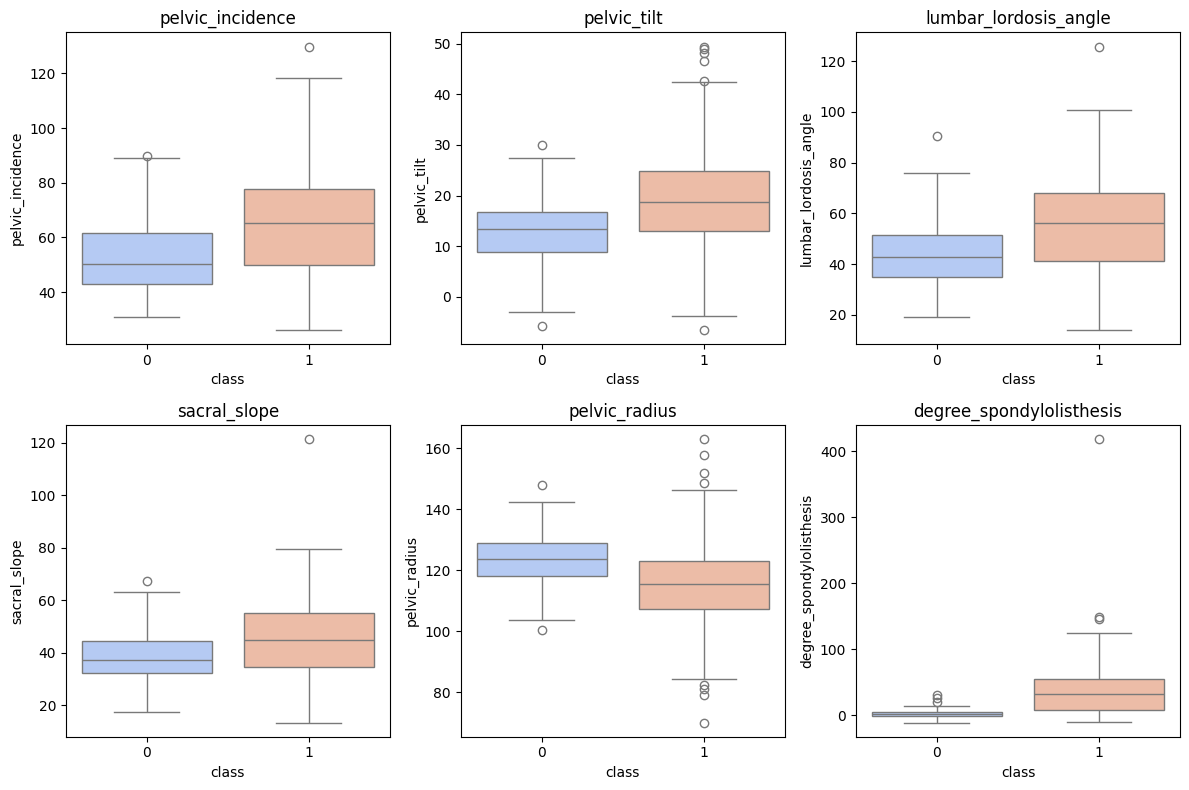

In [ ]:
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.columns[:-1]):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x="class", y=column, data=data, palette="coolwarm")
    plt.title(column)
plt.tight_layout()
plt.show()

# Defining the training and testing set

In [ ]:
class_0 = data[data['class'] == 0].iloc[:70]  # First 70 rows of Class 0
class_1 = data[data['class'] == 1].iloc[:140]  # First 140 rows of Class 1

train_set = pd.concat([class_0, class_1])
test_set = data.drop(train_set.index)  # Remaining data as test set

print("Train set size:", train_set.shape)
print("Test set size:", test_set.shape)

Train set size: (210, 7)
Test set size: (100, 7)


In [ ]:
X_train, y_train = train_set.iloc[:, :-1], train_set.iloc[:, -1]
X_test, y_test = test_set.iloc[:, :-1], test_set.iloc[:, -1]

print("Train set size:", X_train.shape, y_train.shape)
print("Test set size:", X_test.shape, y_test.shape)

Train set size: (210, 6) (210,)
Test set size: (100, 6) (100,)


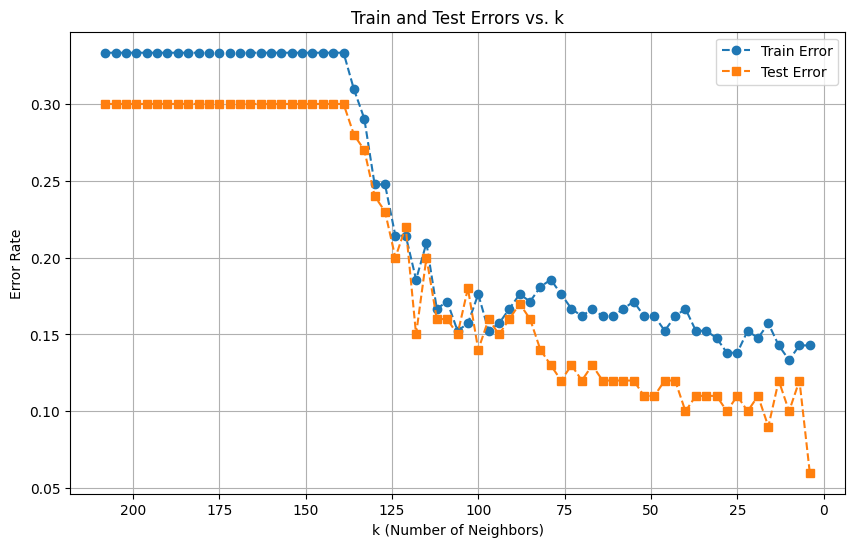

Optimal k: 4


In [ ]:
k_values = list(range(208, 3, -3))  # k from 208 to 4 in decrements of 3
train_errors = []
test_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)

    # Predictions
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate error rates
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    train_errors.append(train_error)
    test_errors.append(test_error)

# Plot errors
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_errors, label='Train Error', marker='o', linestyle='dashed')
plt.plot(k_values, test_errors, label='Test Error', marker='s', linestyle='dashed')
plt.gca().invert_xaxis()
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Error Rate")
plt.title("Train and Test Errors vs. k")
plt.legend()
plt.grid()
plt.show()

# Find the best k (minimum test error)
optimal_k = k_values[np.argmin(test_errors)]
print("Optimal k:", optimal_k)

#Train KNN with optimal value of K



In [ ]:
# Train KNN with optimal k
knn_opt = KNeighborsClassifier(n_neighbors=optimal_k, metric='euclidean')
knn_opt.fit(X_train, y_train)

# Predictions
y_pred_opt = knn_opt.predict(X_test)

# Confusion matrix and performance metrics
conf_matrix = confusion_matrix(y_test, y_pred_opt)
tp = conf_matrix[1, 1]  # True Positives
tn = conf_matrix[0, 0]  # True Negatives
fp = conf_matrix[0, 1]  # False Positives
fn = conf_matrix[1, 0]  # False Negatives

tpr = tp / (tp + fn)  # True Positive Rate (Recall)
tnr = tn / (tn + fp)  # True Negative Rate
precision = precision_score(y_test, y_pred_opt)
f1 = f1_score(y_test, y_pred_opt)

print("Confusion Matrix:\n", conf_matrix)
print(f"True Positive Rate (Recall): {tpr:.4f}")
print(f"True Negative Rate: {tnr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

Confusion Matrix:
 [[25  5]
 [ 1 69]]
True Positive Rate (Recall): 0.9857
True Negative Rate: 0.8333
Precision: 0.9324
F1-score: 0.9583


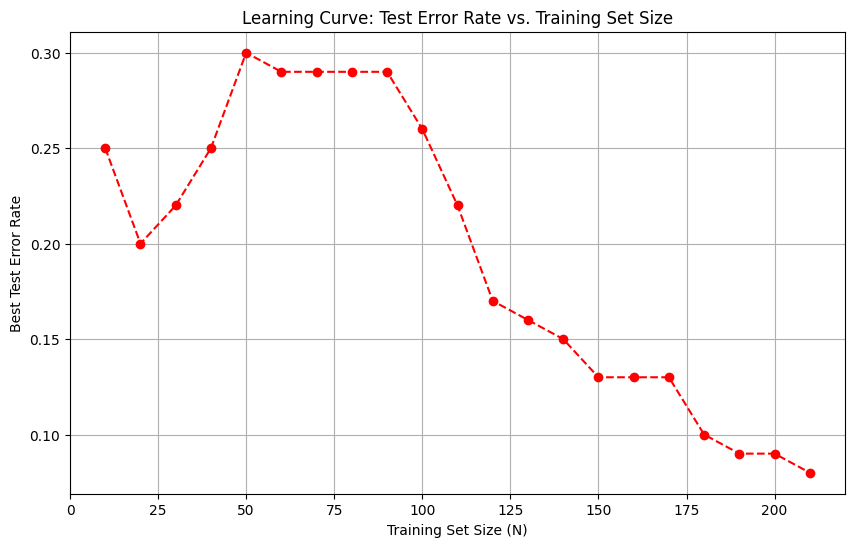

In [ ]:
train_sizes = list(range(10, 211, 10))  # Training sizes from 10 to 210 in steps of 10
test_errors_opt = []

for N in train_sizes:
    # Select N/3 (floor) rows of Class 0 and N - N/3 (floor) rows of Class 1
    num_class_0 = N // 3
    num_class_1 = N - num_class_0

    class_0_subset = train_set[train_set['class'] == 0].iloc[:num_class_0]
    class_1_subset = train_set[train_set['class'] == 1].iloc[:num_class_1]
    subset_train = pd.concat([class_0_subset, class_1_subset])

    X_train_subset, y_train_subset = subset_train.iloc[:, :-1], subset_train.iloc[:, -1]

    # Select optimal k for this subset (starting from k=1, increasing by 5)
    k_options = list(range(1, N, 5))
    min_error = float("inf")
    best_k_for_N = 1

    for k in k_options:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_train_subset, y_train_subset)
        y_test_pred = knn.predict(X_test)
        error_rate = 1 - accuracy_score(y_test, y_test_pred)

        if error_rate < min_error:
            min_error = error_rate
            best_k_for_N = k

    test_errors_opt.append(min_error)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, test_errors_opt, marker='o', linestyle='dashed', color='r')
plt.xlabel("Training Set Size (N)")
plt.ylabel("Best Test Error Rate")
plt.title("Learning Curve: Test Error Rate vs. Training Set Size")
plt.grid()
plt.show()

In [ ]:
def evaluate_knn(metric, p=None):
    k_values = list(range(1, 197, 5))  # {1,6,11,...,196}
    test_errors = {}

    for k in k_values:
        if metric == "mahalanobis":
            try:
                cov_matrix = np.cov(X_train.T)
                cov_inv = inv(cov_matrix)
            except LinAlgError:
                cov_inv = pinv(cov_matrix)  # Use pseudoinverse if singular

            knn = KNeighborsClassifier(n_neighbors=k, metric=mahalanobis, metric_params={'VI': cov_inv})
        else:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=p)

        knn.fit(X_train, y_train)
        y_test_pred = knn.predict(X_test)
        test_error = 1 - accuracy_score(y_test, y_test_pred)

        test_errors[k] = test_error

    best_k = min(test_errors, key=test_errors.get)
    return best_k, test_errors[best_k]

In [ ]:
best_k_manhattan, error_manhattan = evaluate_knn(metric="minkowski", p=1)

# ii. Minkowski with log10(p) {0.1,0.2,...,1}
log_p_values = np.arange(0.1, 1.1, 0.1)
best_log_p = None
best_log_p_error = float("inf")

for log_p in log_p_values:
    p_value = 10 ** log_p
    _, error = evaluate_knn(metric="minkowski", p=p_value)

    if error < best_log_p_error:
        best_log_p_error = error
        best_log_p = log_p

# iii. Chebyshev Distance (p -> ∞)
best_k_chebyshev, error_chebyshev = evaluate_knn(metric="chebyshev")

# iv. Mahalanobis Distance
best_k_mahalanobis, error_mahalanobis = evaluate_knn(metric="mahalanobis")

In [ ]:
summary_df = pd.DataFrame({
    "Metric": ["Manhattan (p=1)", "Minkowski (log10(p))", "Chebyshev (p -> ∞)", "Mahalanobis"],
    "Best k": [best_k_manhattan, best_k_manhattan, best_k_chebyshev, best_k_mahalanobis],
    "Test Error": [error_manhattan, best_log_p_error, error_chebyshev, error_mahalanobis],
    "Best log10(p)": [None, best_log_p, None, None]
})

print(summary_df)

                 Metric  Best k  Test Error  Best log10(p)
0       Manhattan (p=1)       1        0.11            NaN
1  Minkowski (log10(p))       1        0.06            0.6
2    Chebyshev (p -> ∞)      16        0.08            NaN
3           Mahalanobis       1        0.15            NaN


#Weighted Voting with different distances as weights

In [ ]:
def evaluate_weighted_knn(metric, p=None):
    k_values = list(range(1, 197, 5))  # {1,6,11,...,196}
    test_errors = {}

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=p, weights="distance")
        knn.fit(X_train, y_train)
        y_test_pred = knn.predict(X_test)
        test_error = 1 - accuracy_score(y_test, y_test_pred)
        test_errors[k] = test_error

    best_k = min(test_errors, key=test_errors.get)
    return best_k, test_errors[best_k]

In [ ]:
# Weighted KNN with Euclidean Distance (default Minkowski with p=2)
best_k_euclidean, error_euclidean = evaluate_weighted_knn(metric="minkowski", p=2)

# Weighted KNN with Manhattan Distance (p=1)
best_k_manhattan, error_manhattan = evaluate_weighted_knn(metric="minkowski", p=1)

# Weighted KNN with Chebyshev Distance (p → ∞)
best_k_chebyshev, error_chebyshev = evaluate_weighted_knn(metric="chebyshev")

In [ ]:
summary_weighted_df = pd.DataFrame({
    "Metric": ["Euclidean", "Manhattan", "Chebyshev"],
    "Best k": [best_k_euclidean, best_k_manhattan, best_k_chebyshev],
    "Test Error": [error_euclidean, error_manhattan, error_chebyshev]
})

print(summary_weighted_df)

      Metric  Best k  Test Error
0  Euclidean       6        0.10
1  Manhattan      26        0.10
2  Chebyshev      16        0.11


#The lowest training error acheived in this homework:


In [ ]:
train_error = 1 - accuracy_score(y_train, KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train).predict(X_train))
print(f"Lowest Training Error Rate: {train_error}")

Lowest Training Error Rate: 0.0
